SHAP values for modelling 3 CatBoost models

# Import libraries

In [1]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter(action='ignore', category=NumbaDeprecationWarning)

In [2]:
import shap
import joblib
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(
    str(Path('..', 'utils_functionality', 'split_utils'))
)
sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling3_utils import (
    # _prepare_df,
    MLPipeline,
    _create_pipeline,
    StatsModelsEstimator,
)

# Splashing

In [3]:
pipeline_spl = joblib.load('../results/models_modelling3/CatBoostClassifier_splashing_base')
cb_model = pipeline_spl.steps[3][1]

In [4]:
ml_pipe = MLPipeline(
    target='splashing',
    estimator=cb_model,
    features_to_drop = (
        'Re', 
        'We', 
        'init_volume_fraction',
        'particle_droplet_diameter_ratio', 
        'sedimentation_Re',
        # 'particle_liquid_density_ratio',
        'sedimentation_Stk'
        # 'sign_sedimentation_Re',
        # 'volume_fraction', 
        # 'relative_roughness', 
        # 'inclination',
        # 'wettability',
    ),
    model_postfix='test',)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


None

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sign_sedimentation_Re',
                                  'particle_liquid_density_ratio',
                                  'relative_roughness', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

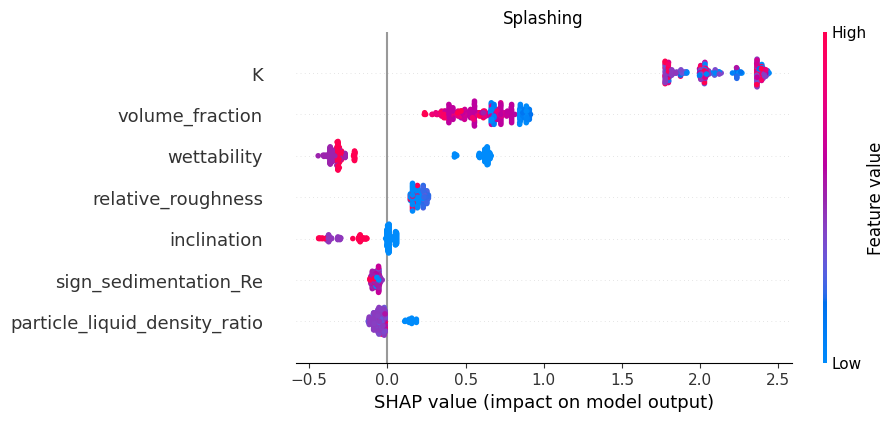

In [5]:
X = ml_pipe.train[cb_model.feature_names_]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values, show=False)
plt.title('Splashing')
plt.show()

# No fragmentation

In [6]:
pipeline_spl = joblib.load('../results/models_modelling3/CatBoostClassifier_no_fragmentation_base')
cb_model = pipeline_spl.steps[3][1]

In [7]:
ml_pipe = MLPipeline(
    target='no_fragmentation',
    estimator=cb_model,
    features_to_drop = (
        'Re', 
        'We', 
        'init_volume_fraction',
        'particle_droplet_diameter_ratio', 
        'sedimentation_Re',
        # 'particle_liquid_density_ratio',
        'sedimentation_Stk'
        # 'sign_sedimentation_Re',
        # 'volume_fraction', 
        # 'relative_roughness', 
        # 'inclination',
        # 'wettability',
    ),
    model_postfix='test',)

Load dataset from: ../data/df_dimless.xlsx
Keep "no_fragmentation" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_no_fragmentation.xlsx
std_features


None

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sign_sedimentation_Re',
                                  'particle_liquid_density_ratio',
                                  'relative_roughness', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

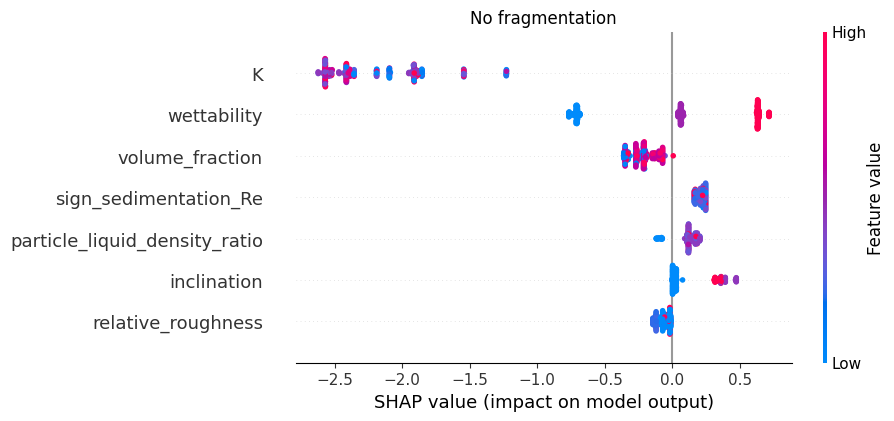

In [8]:
X = ml_pipe.train[cb_model.feature_names_]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values, show=False)
plt.title('No fragmentation')
plt.show()